In [1]:
import pandas as pd
import requests
from datetime import date, timedelta, datetime
import matplotlib.pyplot as plt
import json

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

## Hourly data

In [3]:
"""
'fetch_hourly_rawdata' takes latitude and longitude of the place
you need to find the weather data on, and fetches the hourly weather data 
for that place in JSON format
It provides hourly data for a total of 8 days which includes the hourly weather 
for the next(future) 3 days.
"""
def fetch_hourly_metric_data(lat, lng):

    url = "https://api.open-meteo.com/v1/forecast"

    today = date.today()

    past_date = today - timedelta(days=4)
    future_date = today + timedelta(days=3)

    params = {
        "latitude": lat,
        "longitude": lng,
        "hourly": [
            "temperature_2m",
            "relative_humidity_2m",
            "precipitation",
            "wind_speed_10m",
            "cloud_cover",
            "surface_pressure",
            "wind_direction_10m"
        ],
        "start_date": past_date.isoformat(),
        "end_date": future_date.isoformat(),
        "timezone": "auto"
    }

    response = requests.get(url, params=params)

    # convert response to JSON
    data = response.json()

    return data

In [4]:
"""
Fetches hourly weather data in imperial units (Fahrenheit, mph, inches).
Default range: past 4 days + next 3 days.
Returns raw JSON from Open-Meteo API.
"""
def hourly_imperial_data(lat, lng):

    url = "https://api.open-meteo.com/v1/forecast"

    today = date.today()

    past_date = today - timedelta(days=4)
    future_date = today + timedelta(days=3)

    params = {
        "latitude": lat,
        "longitude": lng,
        "hourly": [
            "temperature_2m",
            "relative_humidity_2m",
            "precipitation",
            "wind_speed_10m",
            "cloud_cover",
            "surface_pressure",
            "wind_direction_10m"
        ],
        "start_date": past_date.isoformat(),
        "end_date": future_date.isoformat(),
        "timezone": "auto",
        "temperature_unit": "fahrenheit",
        "wind_speed_unit": "mph",
        "precipitation_unit": "inch",

    }

    response = requests.get(url, params=params)

    # convert response to JSON
    data = response.json()

    return data

In [5]:
"""
This 'data_in_table' function converts the hourly data fetched from the open meteo API, 
which is in JSON format to a Pandas dataframe.
So what it takes as argument is the data one gets from 'fetch_hourly_rawdata(lat, lng)'
and returns a 2-D table.
"""
def data_in_table(raw_data):

    df_raw = pd.DataFrame()
       
    df_raw['time'] = raw_data['hourly']['time']
    df_raw['temperature_2m'] = raw_data['hourly']['temperature_2m']
    df_raw['relative_humidity_2m'] = raw_data['hourly']['relative_humidity_2m']
    df_raw['precipitation'] = raw_data['hourly']['precipitation']
    df_raw['cloud_cover'] = raw_data['hourly']['cloud_cover']
    df_raw['surface_pressure'] = raw_data['hourly']['surface_pressure']
    df_raw['wind_speed_10m'] = raw_data['hourly']['wind_speed_10m']
    df_raw['wind_direction_10m'] = raw_data['hourly']['wind_direction_10m']

    return df_raw

In [7]:
"""
Returns the units that the hourly weather data (raw_data) that is fetched, uses.
"""
def hourly_data_units(raw_data):
    # for paramtr, hrl_unit in raw_data['hourly_units'].items():
        # print(hrl_unit)
    return raw_data['hourly_units']

## Daily data

In [8]:
"""
'fetch_daily_data' takes latitude and longitude of the place
you need to find the weather data on, & optionally the start and end date 
in case you want to specify the timeframe, and fetches the daily weather data 
for that place in JSON format
The default duration is past 30 days.
The default data units use metric system.
"""
def fetch_daily_data(lat, lng, from_date = date.today()-timedelta(days=30), to_date = date.today()-timedelta(days=1)):

    url = "https://archive-api.open-meteo.com/v1/archive"
    
    params = {
    "latitude": lat,
	"longitude": lng,
    "start_date": from_date.isoformat(),
	"end_date": to_date.isoformat(),
	"daily": ["temperature_2m_max", 
           "temperature_2m_min", 
           "wind_direction_10m_dominant", 
           "wind_speed_10m_max", 
           "sunshine_duration", 
           "precipitation_sum", 
           "apparent_temperature_mean"],
    }
    response = requests.get(url, params=params)
    #response.raise_for_status()


    # convert response to JSON
    daily_data = response.json()

    return daily_data

In [9]:
"""
'raw_daily_data_imperial' takes latitude and longitude of the place
you need to find the weather data on, & optionally the start and end date 
in case you want to specify the timeframe, and fetches the daily weather data 
for that place in JSON format
The default duration is past 30 days.
The default data units use imperial system.
"""
def raw_daily_data_imperial(lat, lng, from_date = date.today()-timedelta(days=30), to_date = date.today()-timedelta(days=1)):

    url = "https://archive-api.open-meteo.com/v1/archive"
 
    params = {
    "latitude": lat,
	"longitude": lng,
    "start_date": from_date.isoformat(),
	"end_date": to_date.isoformat(),
	"daily": ["temperature_2m_max", 
           "temperature_2m_min", 
           "wind_direction_10m_dominant", 
           "wind_speed_10m_max", 
           "sunshine_duration", 
           "precipitation_sum", 
           "apparent_temperature_mean"],
    "temperature_unit": "fahrenheit",
	"wind_speed_unit": "mph",
	"precipitation_unit": "inch",

    }
    response = requests.get(url, params=params)
    response.raise_for_status()


    # convert response to JSON
    daily_data = response.json()

    return daily_data

In [10]:
"""
This 'daily_data_table' function converts the daily data fetched from the open meteo API, 
which is in JSON format to a Pandas dataframe.
So what it takes as argument is the data one gets from 'fetch_daily_data(lat, lng,....)'
and returns a 2-D table.
"""
def daily_data_table(daily_data):

    df_daily = pd.DataFrame()

    df_daily['time'] = daily_data['daily']['time']
    df_daily['temperature_2m_min'] = daily_data['daily']['temperature_2m_min']
    df_daily['temperature_2m_max'] = daily_data['daily']['temperature_2m_max']
    df_daily['apparent_temperature_mean'] = daily_data['daily']['apparent_temperature_mean']
    df_daily['precipitation_sum'] = daily_data['daily']['precipitation_sum']
    df_daily['sunshine_duration'] = daily_data['daily']['sunshine_duration']
    df_daily['wind_speed_10m_max'] = daily_data['daily']['wind_speed_10m_max']
    df_daily['wind_direction_10m_dominant'] = daily_data['daily']['wind_direction_10m_dominant']

    return df_daily

In [11]:
"""
Returns the units that the daily weather data (daily_data) that is fetched uses.
"""
def daily_data_units(daily_data):

    return daily_data['daily_units']

## Tests - Data Fetching

In [13]:
raw_data = fetch_hourly_metric_data(52.52, 13.41)
# raw_data = hourly_imperial_data(52.52, 13.41)
df_hourly = data_in_table(raw_data)
df_hourly

,time,temperature_2m,relative_humidity_2m,precipitation,cloud_cover,surface_pressure,wind_speed_10m,wind_direction_10m
0,2026-04-16T00:00,11.8,54,0.0,79,1016.8,5.2,115
1,2026-04-16T01:00,11.0,56,0.0,93,1016.6,5.5,113
2,2026-04-16T02:00,10.3,59,0.0,93,1016.9,6.1,118
3,2026-04-16T03:00,9.9,61,0.0,98,1016.0,5.6,130
4,2026-04-16T04:00,9.7,62,0.0,100,1015.9,4.6,135
...,...,...,...,...,...,...,...,...
187,2026-04-23T19:00,14.3,57,0.0,52,1016.5,12.5,321
188,2026-04-23T20:00,13.4,63,0.0,0,1016.7,9.8,324
189,2026-04-23T21:00,12.4,67,0.0,0,1016.8,8.2,322
190,2026-04-23T22:00,11.2,73,0.0,0,1016.9,6.4,313


In [ ]:
# data = df_hourly.to_dict()

# # writing dictionary to a file as JSON
# with open('hourly_metric.json', 'w') as f:
#     json.dump(data, f)

In [ ]:
# data = df_hourly.to_dict()

# # writing dictionary to a file as JSON
# with open('hourly_imperial.json', 'w') as f:
#     json.dump(data, f)

In [42]:
raw_data = fetch_daily_data(52.52, 13.41)
# raw_data = raw_daily_data_imperial(52.52, 13.41)
df_daily = daily_data_table(raw_data)
df_daily

,time,temperature_2m_min,temperature_2m_max,apparent_temperature_mean,precipitation_sum,sunshine_duration,wind_speed_10m_max,wind_direction_10m_dominant
0,2026-03-11,7.1,16.0,8.2,0.7,33170.52,19.2,205
1,2026-03-12,5.8,12.9,6.0,0.1,39579.64,16.2,233
2,2026-03-13,4.8,15.2,6.1,0.0,36271.96,23.4,187
3,2026-03-14,5.0,13.9,6.2,1.2,17560.55,18.4,242
4,2026-03-15,4.1,7.2,3.0,0.6,0.00,9.7,300
5,2026-03-16,2.4,8.1,1.3,5.2,27631.45,23.2,226
6,2026-03-17,-0.1,10.4,2.3,0.0,40720.20,9.6,146
7,2026-03-18,0.4,12.8,3.3,0.0,41405.07,10.2,96
8,2026-03-19,1.2,13.9,5.2,0.0,41711.43,7.5,354
9,2026-03-20,4.2,11.1,4.8,0.3,31000.25,11.2,17


In [ ]:
# data = df_daily.to_dict()

# # writing dictionary to a file as JSON
# with open('tabular_daily_imperial.json', 'w') as f:
#     json.dump(data, f)

## Data Analysis (Hourly Data)

In [13]:
# Convert timestamp strings to datetime objects
df_hourly["time"] = pd.to_datetime(df_hourly["time"], utc=True)
df_hourly

,time,temperature_2m,relative_humidity_2m,precipitation,cloud_cover,surface_pressure,wind_speed_10m,wind_direction_10m
0,2026-03-08 00:00:00+00:00,47.2,65,0.0,100,1022.3,3.3,110
1,2026-03-08 01:00:00+00:00,44.9,72,0.0,100,1022.5,3.2,115
2,2026-03-08 02:00:00+00:00,44.1,72,0.0,71,1022.2,2.7,99
3,2026-03-08 03:00:00+00:00,43.2,75,0.0,93,1022.5,2.8,108
4,2026-03-08 04:00:00+00:00,42.6,76,0.0,100,1022.1,3.2,115
...,...,...,...,...,...,...,...,...
187,2026-03-15 19:00:00+00:00,43.7,72,0.0,97,1010.3,2.8,209
188,2026-03-15 20:00:00+00:00,42.7,75,0.0,85,1010.3,3.3,196
189,2026-03-15 21:00:00+00:00,41.5,78,0.0,72,1010.1,3.8,187
190,2026-03-15 22:00:00+00:00,40.4,81,0.0,60,1009.8,4.3,183


In [14]:
from tzlocal import get_localzone 

# Split historical and forecast data
local_tz = get_localzone()   # get local timezone
now = datetime.now(local_tz) # get timezone-aware datetime object
# today = date.today()

# Split archived and forecast data
# .dt.date is used to compare only the date part of the timestamp, ignoring the time part

# Future data (forecast) - 3 days ahead
# df_forecast = df_hourly[df_hourly["time"].dt.date > today]
df_forecast = df_hourly[df_hourly["time"] > now]

# Past data (archived) - 4 days past
# df_archive = df_hourly[df_hourly["time"].dt.date <= today]
df_archive = df_hourly[df_hourly["time"] <= now]

In [15]:
df_archive

,time,temperature_2m,relative_humidity_2m,precipitation,cloud_cover,surface_pressure,wind_speed_10m,wind_direction_10m
0,2026-03-08 00:00:00+00:00,47.2,65,0.0,100,1022.3,3.3,110
1,2026-03-08 01:00:00+00:00,44.9,72,0.0,100,1022.5,3.2,115
2,2026-03-08 02:00:00+00:00,44.1,72,0.0,71,1022.2,2.7,99
3,2026-03-08 03:00:00+00:00,43.2,75,0.0,93,1022.5,2.8,108
4,2026-03-08 04:00:00+00:00,42.6,76,0.0,100,1022.1,3.2,115
...,...,...,...,...,...,...,...,...
112,2026-03-12 16:00:00+00:00,56.3,39,0.0,6,1014.6,9.7,214
113,2026-03-12 17:00:00+00:00,55.8,39,0.0,3,1014.3,8.2,202
114,2026-03-12 18:00:00+00:00,54.8,40,0.0,0,1014.6,6.2,199
115,2026-03-12 19:00:00+00:00,52.7,47,0.0,9,1014.6,5.8,176


In [16]:
df_forecast

,time,temperature_2m,relative_humidity_2m,precipitation,cloud_cover,surface_pressure,wind_speed_10m,wind_direction_10m
117,2026-03-12 21:00:00+00:00,48.7,54,0.0,0,1013.9,6.8,172
118,2026-03-12 22:00:00+00:00,47.1,58,0.0,0,1013.8,6.7,174
119,2026-03-12 23:00:00+00:00,46.0,61,0.0,0,1013.3,6.7,184
120,2026-03-13 00:00:00+00:00,45.0,65,0.0,12,1012.7,6.0,195
121,2026-03-13 01:00:00+00:00,43.8,70,0.0,0,1012.2,6.3,188
...,...,...,...,...,...,...,...,...
187,2026-03-15 19:00:00+00:00,43.7,72,0.0,97,1010.3,2.8,209
188,2026-03-15 20:00:00+00:00,42.7,75,0.0,85,1010.3,3.3,196
189,2026-03-15 21:00:00+00:00,41.5,78,0.0,72,1010.1,3.8,187
190,2026-03-15 22:00:00+00:00,40.4,81,0.0,60,1009.8,4.3,183


Define time intervals for which to plot data:

In [17]:
hours_5 = timedelta(hours=5)
days_1 = timedelta(days=1)

Data from the last 5 hours:

In [18]:
df_5h = df_archive[df_archive["time"] >= (df_archive.iloc[-1].loc["time"] - hours_5).isoformat()]
df_5h

,time,temperature_2m,relative_humidity_2m,precipitation,cloud_cover,surface_pressure,wind_speed_10m,wind_direction_10m
111,2026-03-12 15:00:00+00:00,57.1,35,0.0,0,1015.0,8.2,215
112,2026-03-12 16:00:00+00:00,56.3,39,0.0,6,1014.6,9.7,214
113,2026-03-12 17:00:00+00:00,55.8,39,0.0,3,1014.3,8.2,202
114,2026-03-12 18:00:00+00:00,54.8,40,0.0,0,1014.6,6.2,199
115,2026-03-12 19:00:00+00:00,52.7,47,0.0,9,1014.6,5.8,176
116,2026-03-12 20:00:00+00:00,50.5,52,0.0,100,1014.1,7.0,174


Data from the last 1 day:

In [19]:
df_1d = df_archive[df_archive["time"] >= (df_archive.iloc[-1].loc["time"] - days_1).isoformat()]
df_1d

,time,temperature_2m,relative_humidity_2m,precipitation,cloud_cover,surface_pressure,wind_speed_10m,wind_direction_10m
92,2026-03-11 20:00:00+00:00,55.3,67,0.000,100,1008.1,9.2,203
93,2026-03-11 21:00:00+00:00,53.9,74,0.004,100,1008.6,8.5,203
94,2026-03-11 22:00:00+00:00,53.9,74,0.016,98,1008.8,8.9,219
95,2026-03-11 23:00:00+00:00,53.1,77,0.004,99,1009.3,8.4,238
96,2026-03-12 00:00:00+00:00,52.1,77,0.000,100,1009.7,8.4,248
97,2026-03-12 01:00:00+00:00,51.2,78,0.000,100,1010.2,8.8,251
98,2026-03-12 02:00:00+00:00,50.1,81,0.000,100,1010.9,8.7,269
99,2026-03-12 03:00:00+00:00,49.4,76,0.000,100,1011.8,7.9,285
100,2026-03-12 04:00:00+00:00,48.2,80,0.000,98,1012.7,10.4,293
101,2026-03-12 05:00:00+00:00,46.7,79,0.000,84,1013.4,8.5,288


Min, max and avg over the entire dataset:

In [20]:
min_data = df_hourly.drop("time", axis=1).min()
min_data

temperature_2m           38.9
relative_humidity_2m     35.0
precipitation             0.0
cloud_cover               0.0
surface_pressure        995.8
wind_speed_10m            1.4
wind_direction_10m       99.0
dtype: float64

In [21]:
max_data = df_hourly.drop("time", axis=1).max()
max_data

temperature_2m            62.900
relative_humidity_2m      90.000
precipitation              0.039
cloud_cover              100.000
surface_pressure        1024.600
wind_speed_10m            14.200
wind_direction_10m       353.000
dtype: float64

In [22]:
avg_data = df_hourly.drop("time", axis=1).mean()
avg_data

temperature_2m            49.458333
relative_humidity_2m      64.317708
precipitation              0.000927
cloud_cover               73.302083
surface_pressure        1010.934375
wind_speed_10m             5.937500
wind_direction_10m       199.796875
dtype: float64

In [23]:
# Combine the series into a DataFrame
df_stats = pd.concat([min_data, max_data, avg_data], axis = 1).T
df_stats.rename(index = {0: "min", 1: "max", 2: "avg"}, inplace=True)
df_stats

,temperature_2m,relative_humidity_2m,precipitation,cloud_cover,surface_pressure,wind_speed_10m,wind_direction_10m
min,38.900000,35.000000,0.000000,0.000000,995.800000,1.4000,99.000000
max,62.900000,90.000000,0.039000,100.000000,1024.600000,14.2000,353.000000
avg,49.458333,64.317708,0.000927,73.302083,1010.934375,5.9375,199.796875


## Plot data (Pandas)

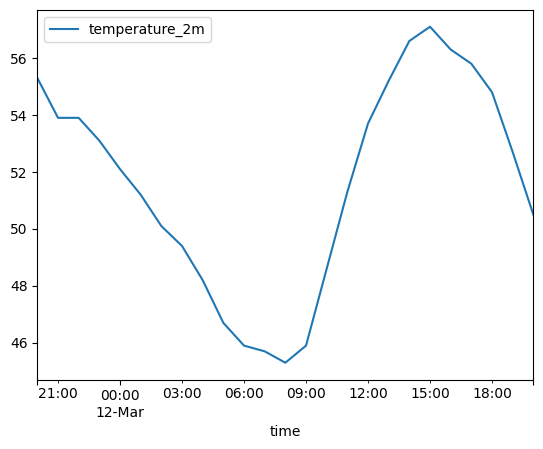

In [24]:
df_1d.plot(x="time", y="temperature_2m")
plt.show()

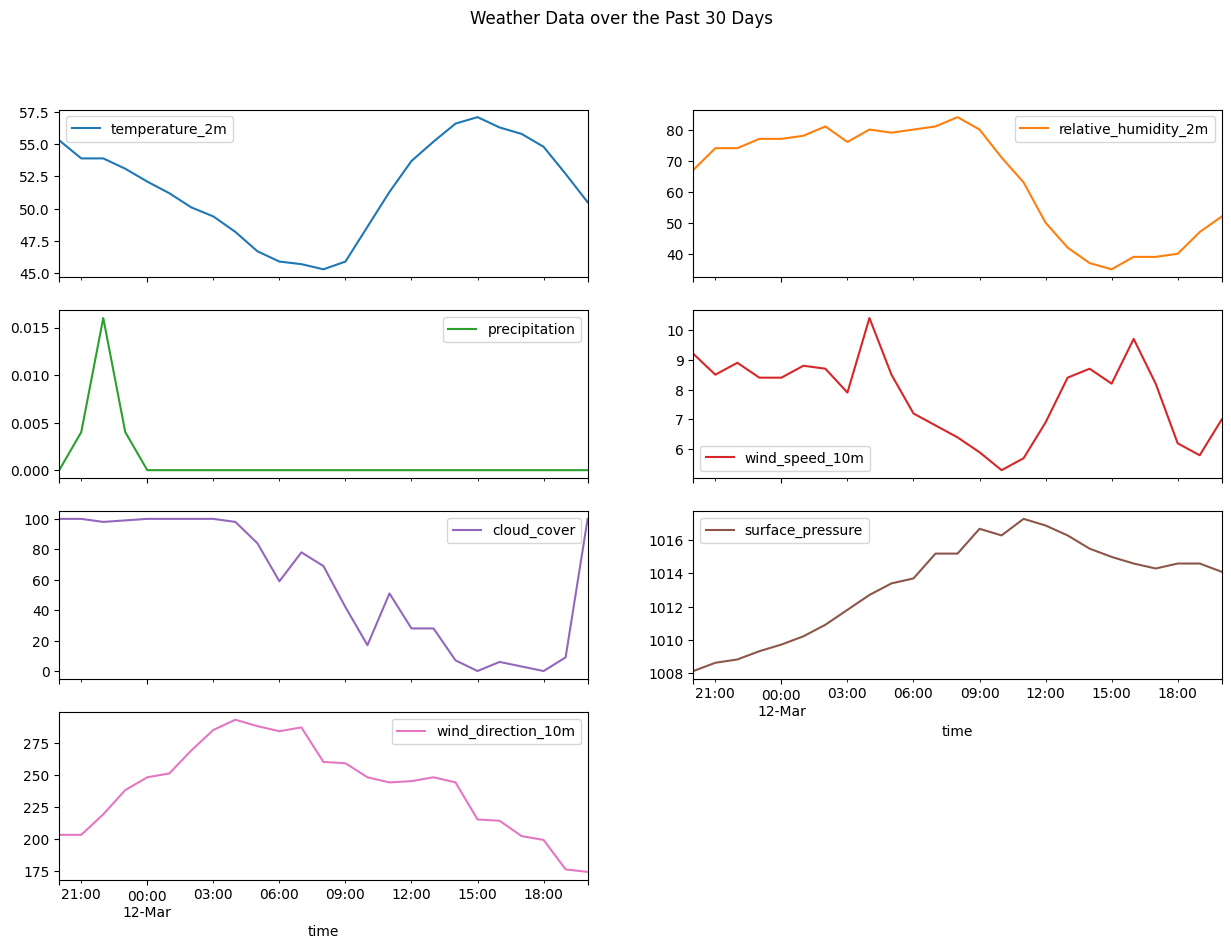

In [25]:
df_1d.plot(
    x="time",
    y=["temperature_2m", "relative_humidity_2m", "precipitation", "wind_speed_10m", "cloud_cover", "surface_pressure", "wind_direction_10m"],
    subplots=True,
    layout=(4,2),
    figsize=(15,10),
    title="Weather Data over the Past 30 Days"
    )
plt.show()

Data correlations:

In [26]:
df_hourly.drop("time", axis=1).corr()

,temperature_2m,relative_humidity_2m,precipitation,cloud_cover,surface_pressure,wind_speed_10m,wind_direction_10m
temperature_2m,1.000000,-0.794841,-0.061124,-0.001462,-0.053821,0.406753,-0.109768
relative_humidity_2m,-0.794841,1.000000,0.223787,0.228105,-0.297261,-0.334362,0.421793
precipitation,-0.061124,0.223787,1.000000,0.175423,-0.307049,0.091120,0.196056
cloud_cover,-0.001462,0.228105,0.175423,1.000000,-0.289565,-0.148852,0.199239
surface_pressure,-0.053821,-0.297261,-0.307049,-0.289565,1.000000,-0.342612,-0.608634
wind_speed_10m,0.406753,-0.334362,0.091120,-0.148852,-0.342612,1.000000,0.210714
wind_direction_10m,-0.109768,0.421793,0.196056,0.199239,-0.608634,0.210714,1.000000


We can plot data that are strongly correlated.

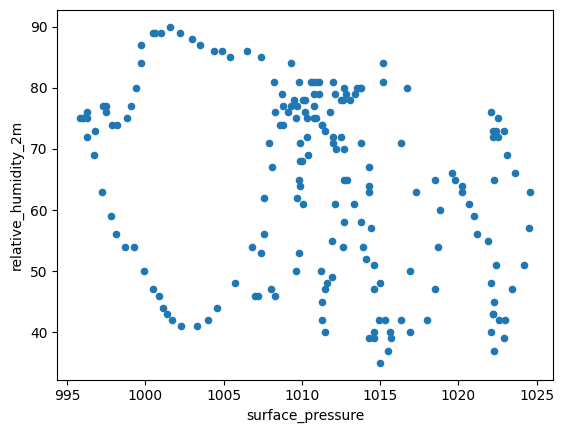

In [27]:
df_hourly.plot(x="surface_pressure", y="relative_humidity_2m", kind="scatter")
plt.show()

In [28]:
def analyze_data_hourly(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Analyze the hourly weather data and calculate min, max and average values for different time intervals.
    The hourly data include today's data, archived data up to 4 days and forecast data up to 3 days.

    Args:
        df (pd.DataFrame): DataFrame containing weather data with a 'time' column.

    Returns:
        tuple: A tuple containing DataFrames for archived data (5 hours, 1 day, and 4 days) and forecast data (3 days),
               as well as DataFrames with min, max, and average statistics for each interval.
    """

    # Convert timestamp strings to datetime objects
    df["time"] = pd.to_datetime(df["time"], utc=True)

    local_tz = get_localzone()  # get local timezone
    now = datetime.now(local_tz)  # get timezone-aware datetime object

    hours_5 = timedelta(hours=5)
    days_1 = timedelta(days=1)

    # Split archived and forecast data

    # Future data (forecast) - 3 days ahead
    df_forecast = df[df["time"] > now]

    # Past data (archived) - 4 days past
    df_archive = df[df["time"] <= now]

    # From now, go back 5 hours and 1 day
    # This assumes that the DataFrame is sorted by time in ascending order
    mask_5h = (df_archive["time"] >= (df_archive.iloc[-1].loc["time"] - hours_5).isoformat())

    mask_1d = (df_archive["time"] >= (df_archive.iloc[-1].loc["time"] - days_1).isoformat())

    df_5h = df_archive[mask_5h]
    df_1d = df_archive[mask_1d]

    # Calculate min, max and average values for the entire DataFrame
    min_data = df.drop("time", axis=1).min()
    max_data = df.drop("time", axis=1).max()
    avg_data = df.drop("time", axis=1).mean()

    # Calculate min, max and average values for the 5 hour DataFrame
    min_data_5h = df_5h.drop("time", axis=1).min()
    max_data_5h = df_5h.drop("time", axis=1).max()
    avg_data_5h = df_5h.drop("time", axis=1).mean()

    # Calculate min, max and average values for the 1 day DataFrame
    min_data_1d = df_1d.drop("time", axis=1).min()
    max_data_1d = df_1d.drop("time", axis=1).max()
    avg_data_1d = df_1d.drop("time", axis=1).mean()

    # Calculate min, max and average values for the archived 4 day DataFrame
    min_data_archive = df_archive.drop("time", axis=1).min()
    max_data_archive = df_archive.drop("time", axis=1).max()
    avg_data_archive = df_archive.drop("time", axis=1).mean()

    # Calculate min, max and average values for the forecast 3 day DataFrame
    min_data_forecast = df_forecast.drop("time", axis=1).min()
    max_data_forecast = df_forecast.drop("time", axis=1).max()
    avg_data_forecast = df_forecast.drop("time", axis=1).mean()

    # Combine the series into a DataFrame (first combine into columns and then transpose)
    df_stats = pd.concat([min_data, max_data, avg_data], axis=1).T
    df_stats_5h = pd.concat([min_data_5h, max_data_5h, avg_data_5h], axis=1).T
    df_stats_1d = pd.concat([min_data_1d, max_data_1d, avg_data_1d], axis=1).T
    df_stats_archive = pd.concat([min_data_archive, max_data_archive, avg_data_archive], axis=1).T
    df_stats_forecast = pd.concat([min_data_forecast, max_data_forecast, avg_data_forecast], axis=1).T

    # Rename the row labels
    df_stats.rename(index={0: "min", 1: "max", 2: "avg"}, inplace=True)
    df_stats_5h.rename(index={0: "min", 1: "max", 2: "avg"}, inplace=True)
    df_stats_1d.rename(index={0: "min", 1: "max", 2: "avg"}, inplace=True)
    df_stats_archive.rename(index={0: "min", 1: "max", 2: "avg"}, inplace=True)
    df_stats_forecast.rename(index={0: "min", 1: "max", 2: "avg"}, inplace=True)

    return (df_5h, df_1d, df_archive, df_forecast, df_stats, df_stats_5h, df_stats_1d, df_stats_archive, df_stats_forecast)


if __name__ == "__main__":
    from data_processing import (fetch_hourly_metric_data, hourly_imperial_data, data_in_table, hourly_data_units)

    raw_data = fetch_hourly_metric_data(52.52, 13.41)
    df_hourly = data_in_table(raw_data)
    print(analyze_data_hourly(df_hourly)[0])  # Print 5 hour DataFrame for testing


                         time  temperature_2m  relative_humidity_2m  \
111 2026-03-12 15:00:00+00:00            13.9                    35   
112 2026-03-12 16:00:00+00:00            13.5                    39   
113 2026-03-12 17:00:00+00:00            13.2                    39   
114 2026-03-12 18:00:00+00:00            12.6                    40   
115 2026-03-12 19:00:00+00:00            11.5                    47   
116 2026-03-12 20:00:00+00:00            10.3                    52   

     precipitation  cloud_cover  surface_pressure  wind_speed_10m  \
111            0.0            0            1015.0            13.2   
112            0.0            6            1014.6            15.6   
113            0.0            3            1014.3            13.2   
114            0.0            0            1014.6             9.9   
115            0.0            9            1014.6             9.4   
116            0.0          100            1014.1            11.2   

     wind_directio

In [29]:
def analyze_data_daily(df: pd.DataFrame, time_limit: int = 30) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Analyze the daily weather data and calculate min, max and average values for different time intervals.
    The daily data include archived data from yesterday up to a custom time limit set by the user.
    The default time limit is 30 days in the past and the maximum time limit is 90 days in the past.

    Args:
        df (pd.DataFrame): DataFrame containing weather data with a 'time' column.

    Returns:
        tuple: A tuple containing DataFrames for 7 day, 30 day, and 90 day intervals,
               as well as DataFrames with min, max, and average statistics for each interval.
    """

    # Convert timestamp strings to datetime objects
    df["time"] = pd.to_datetime(df["time"], utc=True)

    if time_limit < 1 or time_limit > 90:
        raise ValueError("Time limit must be between 1 and 90 days.")

    days_limit = timedelta(days=time_limit)

    # From the last timestamp, go back a custom time limit set by the user (default is 30 days)
    # This assumes that the DataFrame is sorted by time in ascending order
    df_custom = df[df["time"] >= (df.iloc[-1].loc["time"] - days_limit).isoformat()]

    # Calculate min, max and average values for the entire DataFrame
    min_data = df.drop("time", axis=1).min()
    max_data = df.drop("time", axis=1).max()
    avg_data = df.drop("time", axis=1).mean()

    # Calculate min, max and average values for the custom time limit DataFrame
    min_data_custom = df_custom.drop("time", axis=1).min()
    max_data_custom = df_custom.drop("time", axis=1).max()
    avg_data_custom = df_custom.drop("time", axis=1).mean()

    # Combine the series into a DataFrame (first combine into columns and then transpose)
    df_stats = pd.concat([min_data, max_data, avg_data], axis=1).T
    df_stats_custom = pd.concat([min_data_custom, max_data_custom, avg_data_custom], axis=1).T

    # Rename the row labels
    df_stats.rename(index={0: "min", 1: "max", 2: "avg"}, inplace=True)
    df_stats_custom.rename(index={0: "min", 1: "max", 2: "avg"}, inplace=True)

    return df_custom, df_stats, df_stats_custom


if __name__ == "__main__":
    from data_processing import (fetch_daily_data, raw_daily_data_imperial, daily_data_table, daily_data_units)

    raw_data = fetch_daily_data(52.52, 13.41)
    df_daily = daily_data_table(raw_data)
    print(analyze_data_daily(df_daily, 2)[0])  # Print custom time limit DataFrame for testing


                        time  temperature_2m_min  temperature_2m_max  \
27 2026-03-09 00:00:00+00:00                 3.0                14.9   
28 2026-03-10 00:00:00+00:00                 2.8                15.2   
29 2026-03-11 00:00:00+00:00                 7.1                16.0   

    apparent_temperature_mean  precipitation_sum  sunshine_duration  \
27                        5.6                0.0           37450.02   
28                        6.8                0.0           39362.35   
29                        8.2                0.7           33170.52   

    wind_speed_10m_max  wind_direction_10m_dominant  
27                12.2                          130  
28                 8.9                          205  
29                19.2                          205  


## Tests

In [30]:
analyze_data_hourly(df_hourly)[3]

,time,temperature_2m,relative_humidity_2m,precipitation,cloud_cover,surface_pressure,wind_speed_10m,wind_direction_10m
117,2026-03-12 21:00:00+00:00,9.3,54,0.0,0,1013.9,10.9,172
118,2026-03-12 22:00:00+00:00,8.4,58,0.0,0,1013.8,10.9,174
119,2026-03-12 23:00:00+00:00,7.8,61,0.0,0,1013.3,10.8,184
120,2026-03-13 00:00:00+00:00,7.2,65,0.0,12,1012.7,9.7,195
121,2026-03-13 01:00:00+00:00,6.5,70,0.0,0,1012.2,10.2,188
...,...,...,...,...,...,...,...,...
187,2026-03-15 19:00:00+00:00,6.5,72,0.0,97,1010.3,4.5,209
188,2026-03-15 20:00:00+00:00,5.9,75,0.0,85,1010.3,5.2,196
189,2026-03-15 21:00:00+00:00,5.3,78,0.0,72,1010.1,6.2,187
190,2026-03-15 22:00:00+00:00,4.6,81,0.0,60,1009.8,6.8,183


## Plot data

In [31]:
def get_plot_title_hourly(
    anlyzd: tuple[pd.DataFrame, ...], duration: str
) -> tuple[pd.DataFrame, str, dict]:
    """
    This function returns the plot title and selects the DataFrames to plot for hourly data
    on basis of the duration selected by user.
    It returns a tuple of:
    1. hourly data as per the selected duration to plot
    2. plot title
    3. dataframe state: min, max, mean for the duration
    """

    if duration == "5hr":
        data_to_plot = anlyzd[1]
        min_max_mean = anlyzd[6]
        plot_title = "Weather over 5 hours"

    elif duration == "24hr":
        data_to_plot = anlyzd[2]
        min_max_mean = anlyzd[7]
        plot_title = "Weather whole day"

    elif duration == "pst_4d":
        data_to_plot = anlyzd[3]
        min_max_mean = anlyzd[8]
        plot_title = "Weather over past 4 days"

    elif duration == "nxt_3d":
        data_to_plot = anlyzd[4]
        min_max_mean = anlyzd[9]
        plot_title = "Weather forcast for next 3 days"

    return (data_to_plot, plot_title, min_max_mean)

In [32]:
anlyzd = analyze_data_hourly(df_hourly)
data_to_plot, plot_title, min_max_mean = get_plot_title_hourly(anlyzd, "5hr")
data_to_plot.head()

,time,temperature_2m,relative_humidity_2m,precipitation,cloud_cover,surface_pressure,wind_speed_10m,wind_direction_10m
92,2026-03-11 20:00:00+00:00,12.9,67,0.0,100,1008.1,14.8,203
93,2026-03-11 21:00:00+00:00,12.1,74,0.1,100,1008.6,13.7,203
94,2026-03-11 22:00:00+00:00,12.1,74,0.4,98,1008.8,14.3,219
95,2026-03-11 23:00:00+00:00,11.7,77,0.1,99,1009.3,13.6,238
96,2026-03-12 00:00:00+00:00,11.1,77,0.0,100,1009.7,13.6,248


In [33]:
min_max_mean

,temperature_2m,relative_humidity_2m,precipitation,cloud_cover,surface_pressure,wind_speed_10m,wind_direction_10m
min,7.40,35.00,0.000,0.00,1008.100,8.600,174.00
max,13.90,84.00,0.400,100.00,1017.300,16.800,293.00
avg,10.84,64.12,0.024,59.04,1013.352,12.496,239.84
